In [40]:
import os
import numpy as np
import pandas as pd
from tifffile import imwrite
from scipy.spatial import KDTree

def compute_knn_features(points, k=5):
    if len(points) == 0:
        return [], [], []

    setX = points['x'] / points['x'].max()
    setY = points['y'] / points['y'].max()
    setZ = points['z'] / points['z'].max()

    coords = np.stack([setX, setY, setZ], axis=1)

    tree = KDTree(coords)
    k_use = min(k, len(coords))
    distances, indices = tree.query(coords, k=k_use)

    distAv = []
    pWT = []
    pC = []

    for i in range(len(indices)):
        neighbor_indices = indices[i]
        neighbor_phenotypes = points.iloc[neighbor_indices]['Phenotype']

        count_WT = sum(p.startswith('WT') for p in neighbor_phenotypes)
        count_C = sum(p.startswith('C') for p in neighbor_phenotypes)
        total = len(neighbor_phenotypes)

        distAv.append(np.median(distances[i]))
        pWT.append(count_WT)
        pC.append(count_C)

    return distAv, pWT, pC

In [22]:
import pandas as pd
import os

pathF = r"Z:\users\6331823\Mario Pipeline\frames-frames_extracted\Second try\cellpose"
dataFolder = pd.read_csv(os.path.join(pathF, "summary_results.csv"), sep=',')
# pattern = r'^(?P<series_id>.+?)-frame-(?P<frame>\d+)\.txt$' #the correct one
pattern = r'^(?P<series_id>.+?)-ref-frame-(?P<frame>\d+)\.tif$' #altered for test

# Aplicar el regex
dataFolder[['series_id', 'frame']] = dataFolder['file'].str.extract(pattern)
print(dataFolder['file'])
# Convertir frame a entero (soporta NaNs)
dataFolder['frame'] = dataFolder['frame'].astype(pd.Int64Dtype())


print(dataFolder['series_id'].unique())

# TARGET_SERIES = "TL09"  # Cambia esto por el ID que necesites
# # Seleccionar solo el target
# dataFolder= dataFolder[dataFolder['series_id'] == TARGET_SERIES]

# spacing_x = 0.325  # micrones por pixel en X
# spacing_y = 0.325  # micrones por pixel en Y
# spacing_z = 1.0    # micrones entre planos

0      Channel-ref-frame-0.tif
1      Channel-ref-frame-1.tif
2     Channel-ref-frame-10.tif
3     Channel-ref-frame-11.tif
4     Channel-ref-frame-12.tif
5     Channel-ref-frame-13.tif
6     Channel-ref-frame-14.tif
7     Channel-ref-frame-15.tif
8     Channel-ref-frame-16.tif
9     Channel-ref-frame-17.tif
10    Channel-ref-frame-18.tif
11    Channel-ref-frame-19.tif
12     Channel-ref-frame-2.tif
13    Channel-ref-frame-20.tif
14    Channel-ref-frame-21.tif
15    Channel-ref-frame-22.tif
16    Channel-ref-frame-23.tif
17    Channel-ref-frame-24.tif
18    Channel-ref-frame-25.tif
19    Channel-ref-frame-26.tif
20    Channel-ref-frame-27.tif
21    Channel-ref-frame-28.tif
22    Channel-ref-frame-29.tif
23     Channel-ref-frame-3.tif
24    Channel-ref-frame-30.tif
25    Channel-ref-frame-31.tif
26    Channel-ref-frame-32.tif
27    Channel-ref-frame-33.tif
28    Channel-ref-frame-34.tif
29    Channel-ref-frame-35.tif
30    Channel-ref-frame-36.tif
31    Channel-ref-frame-37.tif
32    Ch

In [ ]:
##this is a dirty trick if you just want to insepct a specific series_id
TARGET_SERIES = "TL09"  # Cambia esto por el ID que necesites
# Seleccionar solo el target
# dataFolder= dataFolder[dataFolder['series_id'] == TARGET_SERIES]
###
pathF = r"Z:\users\6331823\Mario Pipeline\frames-frames_extracted\Second try\cellpose"
output_path = os.path.join(pathF, "distances")
os.makedirs(output_path, exist_ok=True)

# Resultados generales
summary_stats = []

for sid in dataFolder['series_id'].unique():
    subset = dataFolder[dataFolder['series_id'] == sid].sort_values(by='frame')
    databyTL = pd.DataFrame()  # DataFrame acumulativo por serie_id

    for _, row in subset.iterrows():
        # fileN = row['file'] + " _quantified.csv"
        fileN = "Channel-ref-frame-" + str(row['frame']) + "_quantified.csv"
        series_id = row['series_id']
        frame = row['frame']
        filePath = os.path.join(pathF, fileN)
        
        try:
            oscarDATA = pd.read_csv(filePath, sep=',')
        except Exception as e:
            print(f"Summary non existent {fileN}: {e}")
            continue
        
        ## i check if the spatial cooridnates x,y,z (named as cx, cy,cz by OSCAR in my case) are present, but you can change the names and verify the columns you need
        if not all(col in oscarDATA.columns for col in ['x', 'y', 'z', 'Phenotype']):
            print(f"Columns are missing in {fileN}")
            continue

        oscarDATA['frame'] = frame
        oscarDATA['series_id'] = series_id

        # Filtrar por fenotipos
        totalCells = len(oscarDATA)
        pointsWT = oscarDATA[oscarDATA['Phenotype'].str.startswith("WT")].copy()
        pointsC = oscarDATA[oscarDATA['Phenotype'].str.startswith("C")].copy()

        # Calcular KNN
        distAv, pWT, pC = compute_knn_features(oscarDATA)
        oscarDATA['K-NN(k=5)'] = distAv
        oscarDATA['Num_WT'] = pWT
        oscarDATA['Num_C'] = pC

        # Guardar estadísticas del archivo actual
        summary_stats.append({
            'file': fileN,
            'series_id': series_id,
            'frame': frame,
            'total_cells': totalCells,
            'WT_cells': len(pointsWT),
            'C_cells': len(pointsC),
            'median_knn_dist': np.median(distAv) if len(distAv) > 0 else np.nan,
            'mean_Num_WT': np.mean(pWT) if len(pWT) > 0 else np.nan,
            'mean_Num_C': np.mean(pC) if len(pC) > 0 else np.nan
        })

        databyTL = pd.concat([databyTL, oscarDATA], ignore_index=True)

    # Guardar datos por serie_id
    temp_path = os.path.join(output_path, f"{sid}_df.txt")
    databyTL.to_csv(temp_path, sep='\t', index=False)   
        
    # #
    if sid == TARGET_SERIES:
        max_frame =   int(databyTL['frame'].max()) + 1
        max_z = int(  databyTL['cz'].max()) + 1
        max_y = int(  databyTL['cy'].max()) + 1
        max_x = int(  databyTL['cx'].max()) + 1
        #
        array_5d = np.zeros((max_frame, 3, max_z, max_y, max_x), dtype=np.uint8)
        for tt in range(max_frame):
            for _, row in databyTL.iterrows():
                x, y, z = int(row['cx']), int(row['cy']), int(row['cz'])
                frame = int(row['frame'])
                phenotype = row['phenotype']
                array_5d[frame, 0, z, y, x] = 255  # Total
                if phenotype.startswith("WT"):
                    array_5d[frame, 1, z, y, x] = 255
                elif phenotype.startswith("C"):
                    array_5d[frame, 2, z, y, x] = 255
    
        # Reorganizar ejes a (T, Z, C, Y, X)
        array_5d = np.transpose(array_5d, (0, 2, 1, 3, 4))

        # Guardar como TIFF con metadatos para ImageJ
        tiff_path = os.path.join(output_path, f"{sid}_stack_TZCYX.tiff")
        imwrite(
            tiff_path,
            array_5d,
            photometric='minisblack',
            metadata={
                'axes': 'TZCYX',  # Especificar orden de ejes
                'spacing': 1,     # Opcional: ajustar según calibración real
                'unit': 'um'      # Opcional: unidades físicas
            },
            imagej=True
        )
        print(f"✅ TIFF guardado correctamente: {tiff_path}")

# Guardar resumen total
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv(os.path.join(output_path, "summary_statistics_KNN.txt"), sep='\t', index=False)


Channel


C:\Users\6331823\AppData\Local\Temp\ipykernel_21356\3328987312.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='TL (series_id)', bbox_to_anchor=(1.05, 1), loc='upper left')


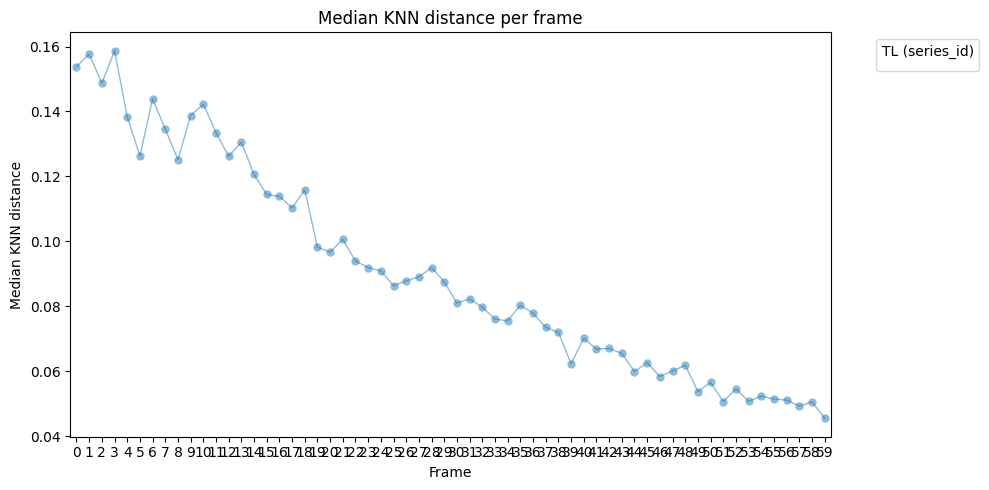

C:\Users\6331823\AppData\Local\Temp\ipykernel_21356\3328987312.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='TL (series_id)', bbox_to_anchor=(1.05, 1), loc='upper left')


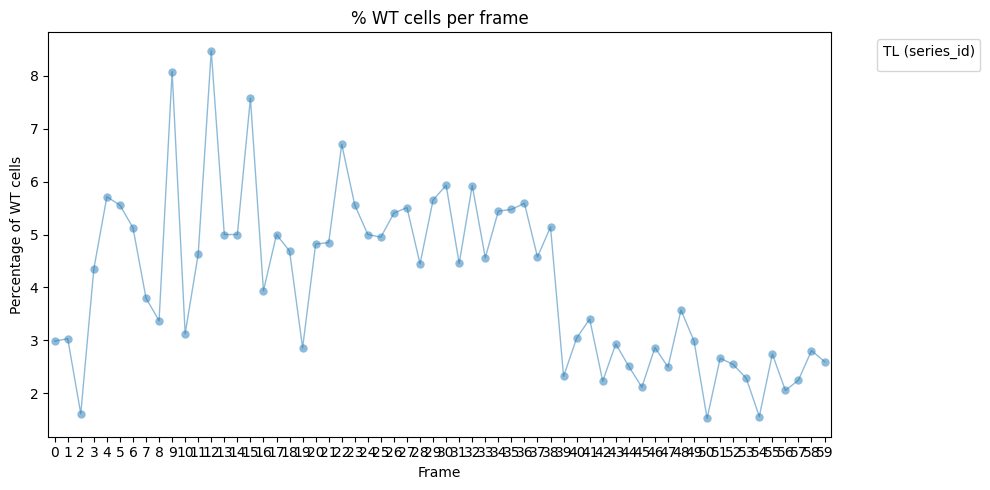

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar tipo correcto
summary_df['frame'] = summary_df['frame'].astype(int)

# Agregar %WT
summary_df['pct_WT'] = summary_df['WT_cells'] / summary_df['total_cells'] * 100

# Calcular medias por frame
mean_df = summary_df.groupby('frame').agg({
    'median_knn_dist': 'mean',
    'pct_WT': 'mean'
}).reset_index()

# --- PLOT Median KNN ---
plt.figure(figsize=(10, 5))

# Líneas por series_id
sns.lineplot(data=summary_df, x='frame', y='median_knn_dist', hue='series_id',
             palette='tab10', linewidth=1, alpha=0.5, legend=False)

# Dots por frame y TL
sns.stripplot(data=summary_df, x='frame', y='median_knn_dist', hue='series_id',
              dodge=True, jitter=False, alpha=0.5, size=6, palette='tab10', legend=False)


plt.title("Median KNN distance per frame")
plt.xlabel("Frame")
plt.ylabel("Median KNN distance")
plt.legend(title='TL (series_id)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- PLOT % WT ---
plt.figure(figsize=(10, 5))

# Líneas por series_id
sns.lineplot(data=summary_df, x='frame', y='pct_WT', hue='series_id',
             palette='tab10', linewidth=1, alpha=0.5, legend=False)

# Dots por frame y TL
sns.stripplot(data=summary_df, x='frame', y='pct_WT', hue='series_id',
              dodge=True, jitter=False, alpha=0.5, size=6, palette='tab10', legend=False)

plt.title("% WT cells per frame")
plt.xlabel("Frame")
plt.ylabel("Percentage of WT cells")
plt.legend(title='TL (series_id)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
